<a href="https://colab.research.google.com/github/sanikatakarkhede/ML_model/blob/main/PRAC_9_Extra_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sanika Takarkhede(CS23016)
Lab 9 Extra Practical: To implement the K-Means clustering algorithm and analyze the clustering results using appropriate evaluation techniques.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
path ="/content/drive/MyDrive/ML_dataset/WineQT.csv"
df=pd.read_csv(path)
df.head(5)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
df.shape

(1143, 13)

In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

In [ ]:
df.isnull().any().any()


np.False_

In [ ]:
X = df[['alcohol', 'quality']]

X.head()


,alcohol,quality
0,9.4,5
1,9.8,5
2,9.8,5
3,9.8,6
4,9.4,5


In [ ]:
X =df.iloc[:,[3,4]].values
print(X)

[[1.9   0.076]
 [2.6   0.098]
 [2.3   0.092]
 ...
 [2.    0.09 ]
 [2.2   0.062]
 [2.    0.075]]


In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)
print(x_scaled)

[[-0.46642142 -0.23139486]
 [ 0.05006018  0.23424656]
 [-0.17128908  0.10725344]
 ...
 [-0.39263833  0.06492241]
 [-0.24507216 -0.52771212]
 [-0.39263833 -0.25256038]]


[2286.0000000000045, 1501.359886091443, 761.3961622476106, 633.4432682350537, 505.9773376469779, 364.2213841246994, 287.7285247528405, 255.17523035093953, 220.57760600687703, 196.71283427684477]


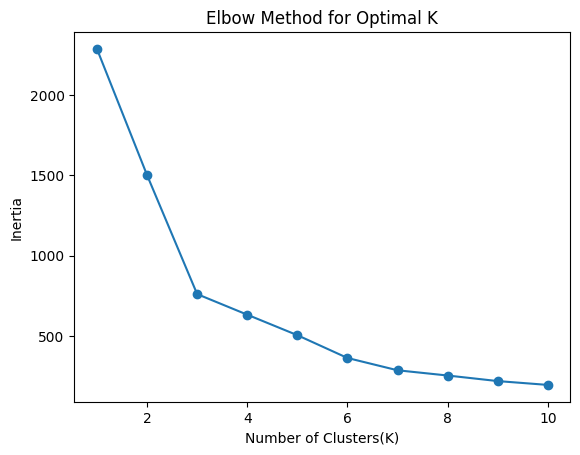

In [ ]:
inertia_values = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k,random_state=42)
  kmeans.fit(x_scaled)
  inertia_values.append(kmeans.inertia_)
print(inertia_values)
plt.figure()
plt.plot(range(1,11),inertia_values,marker='o')
plt.xlabel("Number of Clusters(K)")
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=8,random_state=42)
clusters = kmeans.fit_predict(x_scaled)
df['Cluster'] = clusters
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  Cluster  
0      9.4        5   0        4  
1      9.8      

In [ ]:
print("Inertia:",kmeans.inertia_)
sil_score = silhouette_score(x_scaled,clusters)
print("Silhouette Score:",sil_score)


Inertia: 255.17523035093953
Silhouette Score: 0.3190013060941368


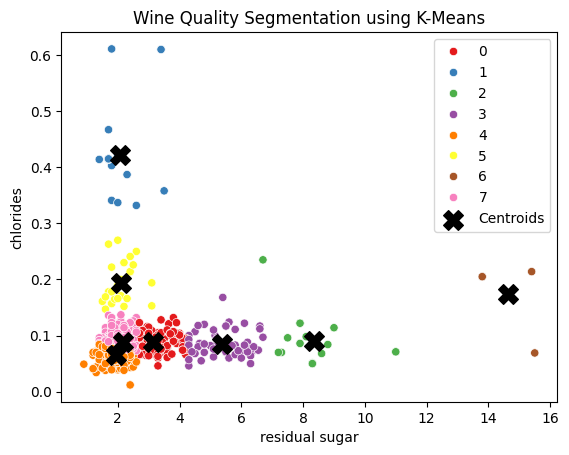

In [ ]:
plt.figure()
sns.scatterplot(x='residual sugar',
                y='chlorides',
                hue='Cluster',data=df,palette='Set1')
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:,0],centroids[:,1],marker='X',s=200,c='black',label='Centroids')
plt.title("Wine Quality Segmentation using K-Means")
plt.legend()
plt.show()